X shape:  (569, 30)
y shape:  (569,)
Classes:  ['malignant' 'benign']
              precision    recall  f1-score   support

           0       0.87      0.79      0.82        42
           1       0.88      0.93      0.91        72

    accuracy                           0.88       114
   macro avg       0.88      0.86      0.87       114
weighted avg       0.88      0.88      0.88       114

Linear SVM Accuracy: 87.72%
Poly SVM Accuracy:  84.21%
RBF SVM Accuracy: 90.35%


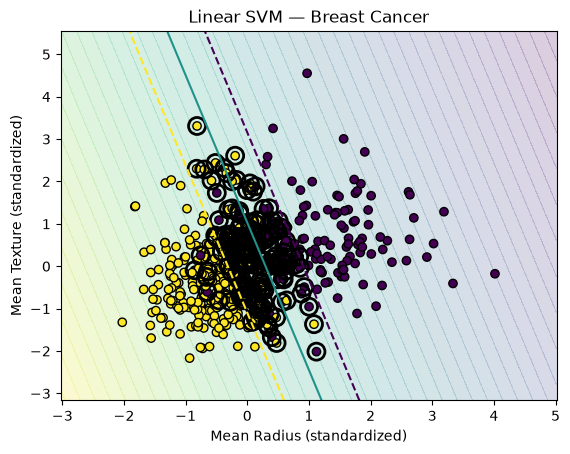

In [5]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import numpy as np
import matplotlib.pyplot as plt

breast_cancer_data = load_breast_cancer()

X = breast_cancer_data.data
y = breast_cancer_data.target

print("X shape: ", X.shape)
print("y shape: ", y.shape)
print("Classes: ", breast_cancer_data.target_names)

# Since this breast_cancer dataset contain alot of features about 30 we have to only use 2 of them so that it will
# be possible for us to visualise the boundaries in 2D insteal or using a multidimensional 30D

X = X[:, [0,1]]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Linear kernel SVM
linear_svm = SVC(kernel='linear', C=0.1)
linear_svm.fit(X_train, y_train)

linear_y_pred = linear_svm.predict(X_test)


print(classification_report(y_test, linear_y_pred))

print(f"Linear SVM Accuracy: {accuracy_score(y_test, linear_y_pred)*100:.2f}%")

# Polynomial Kernel SVM
poly_svm = SVC(kernel='poly', degree=3, C=0.1)
poly_svm.fit(X_train, y_train)

poly_y_pred = poly_svm.predict(X_test)

print(f"Poly SVM Accuracy:  {accuracy_score(y_test, poly_y_pred)*100:.2f}%")


# RBF kernel SVM 

rbf_svm = SVC(kernel="rbf", C=0.1)
rbf_svm.fit(X_train, y_train)

rbf_y_pred = rbf_svm.predict(X_test)

print(f"RBF SVM Accuracy: {accuracy_score(y_test, rbf_y_pred)*100:.2f}%")

# Linear SVM plot
def plot_svm(model, X, y, title):

    x_min = X[:, 0].min() - 1
    x_max = X[:, 0].max() + 1

    y_min = X[:, 1].min() - 1
    y_max = X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 500),
        np.linspace(y_min, y_max, 500)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]

    decision = model.decision_function(grid)
    decision = decision.reshape(xx.shape)

    # Decision regions
    plt.contourf(
        xx,
        yy,
        decision,
        levels=50,
        alpha=0.2
    )

    # Decision boundary + margins
    plt.contour(
        xx,
        yy,
        decision,
        levels=[-1, 0, 1],
        linestyles=["--", "-", "--"]
    )

    # Training points
    plt.scatter(
        X[:, 0],
        X[:, 1],
        c=y,
        edgecolors="k"
    )

    # Support vectors
    plt.scatter(
        model.support_vectors_[:, 0],
        model.support_vectors_[:, 1],
        s=150,
        facecolors="none",
        edgecolors="k",
        linewidths=2
    )

    plt.xlabel("Mean Radius (standardized)")
    plt.ylabel("Mean Texture (standardized)")
    plt.title(title)

    plt.show()

plot_svm(
    linear_svm,
    X_train,
    y_train,
    "Linear SVM — Breast Cancer"
)